In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Reading and Basic Understanding of the Data

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Univariate Analysis

In [8]:
df['Pregnancies'].value_counts()

,count
Pregnancies,
1,135
0,111
2,103
3,75
4,68
5,57
6,50
7,45
8,38


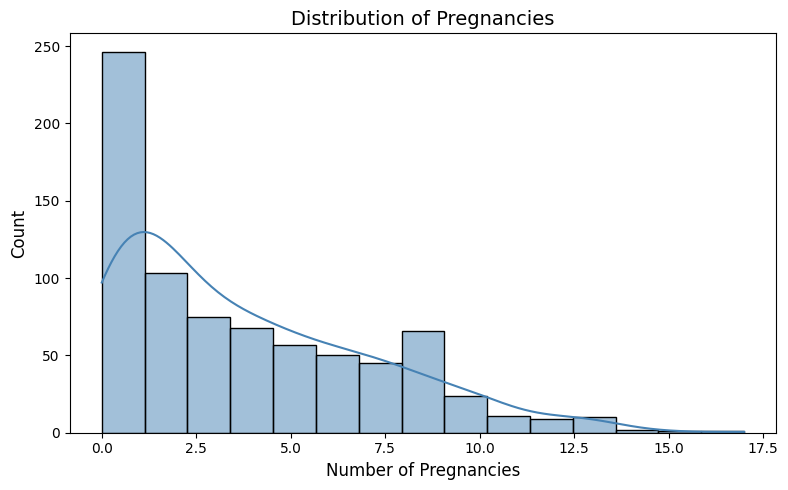

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Pregnancies'], bins=15, kde=True, color='steelblue', edgecolor='black')

plt.title('Distribution of Pregnancies', fontsize=14)
plt.xlabel('Number of Pregnancies', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

#'Pregnancies' has a Right skewwed distribution, which means Majority of the pregnancies seen are around 0 to 4.

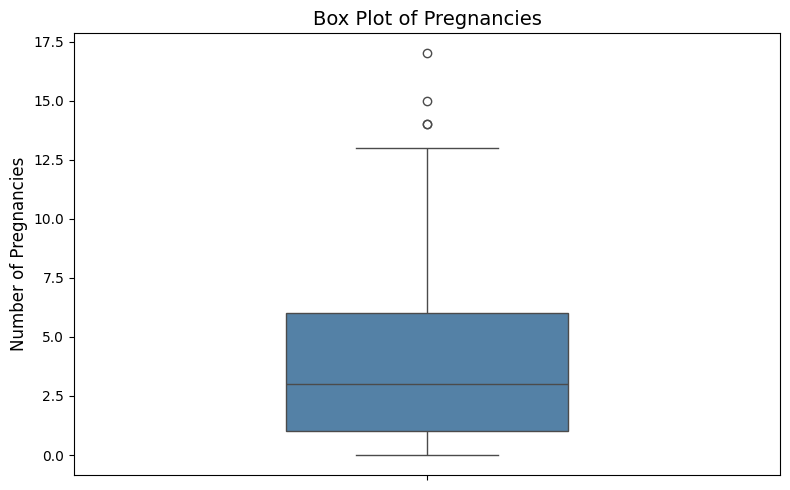

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Pregnancies'], color='steelblue', width=0.4)

plt.title('Box Plot of Pregnancies', fontsize=14)
plt.ylabel('Number of Pregnancies', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#Note1:
#StandardScalar is a concept of standardising values of every feature.
#Every feature is standardised in such a way, so that mean = 0 and std = 1.
#For example, no.of pregnancies of a patient A is 3, and Insulin level is 400. Here Insulin level is clearly dominating no.of pregnancies.
#With Standardization, That will not be a problem. It helps in assigning equal importance to both the feature's values.

In [11]:
df['Glucose'].value_counts()

,count
Glucose,
99,17
100,17
111,14
125,14
129,14
...,...
56,1
169,1
149,1


In [12]:
(df['Glucose'] == 0).sum()
#Glucose can not be 0, as its a very unusual thing to happen.

np.int64(5)

In [13]:
df[df['Glucose'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


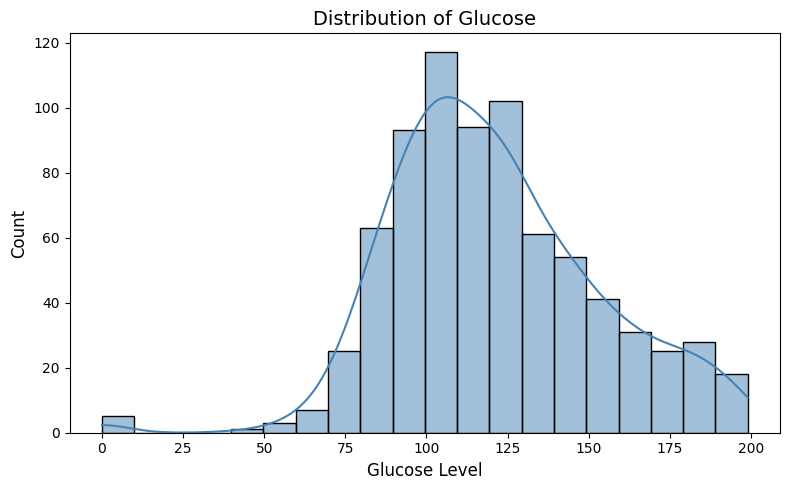

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Glucose'], bins=20, kde=True, color='steelblue', edgecolor='black')

plt.title('Distribution of Glucose', fontsize=14)
plt.xlabel('Glucose Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()
#Almost Normal.
#Might remove those 5 zeroes for even better distribution.

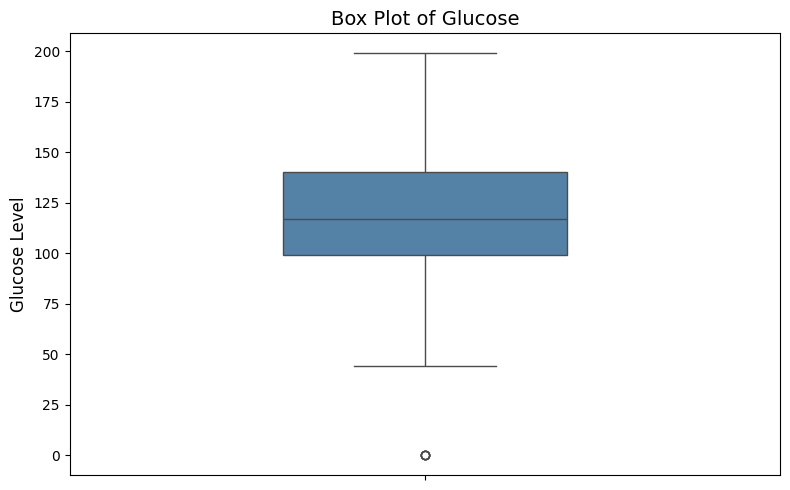

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Glucose'], color='steelblue', width=0.4)

plt.title('Box Plot of Glucose', fontsize=14)
plt.ylabel('Glucose Level', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
df['BloodPressure'].value_counts()

,count
BloodPressure,
70,57
74,52
78,45
68,45
72,44
64,43
80,40
76,39
60,37


In [17]:
(df['BloodPressure']==0).sum()
#There are 39 values below 40 BP, which is unusual, Might consider replacing them.
#Also, There is 1 value above 120 BP, and its 122. So, its pretty close to the range, can be ignored.

np.int64(35)

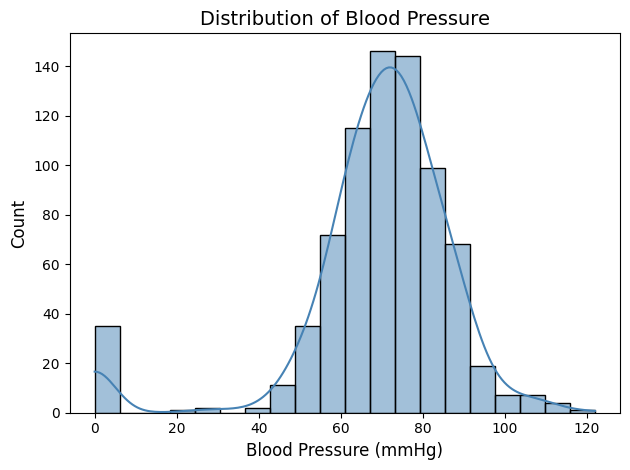

In [18]:
sns.histplot(df['BloodPressure'], bins=20, kde=True, color='steelblue', edgecolor='black')

plt.title('Distribution of Blood Pressure', fontsize=14)
plt.xlabel('Blood Pressure (mmHg)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()
#Normal, but with a spike on O BP, better results without 0, or with replacing.

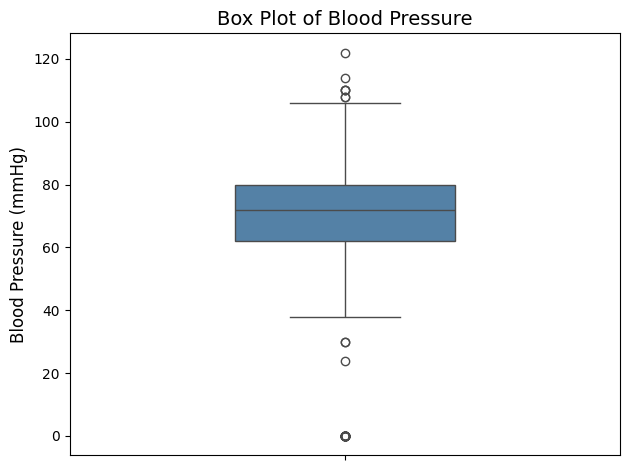

In [19]:
sns.boxplot(y=df['BloodPressure'], color='steelblue', width=0.4)

plt.title('Box Plot of Blood Pressure', fontsize=14)
plt.ylabel('Blood Pressure (mmHg)', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
df['SkinThickness'].value_counts()

,count
SkinThickness,
0,227
32,31
30,27
27,23
23,22
18,20
33,20
28,20
31,19


In [21]:
(df['SkinThickness'] == 0).sum()

np.int64(227)

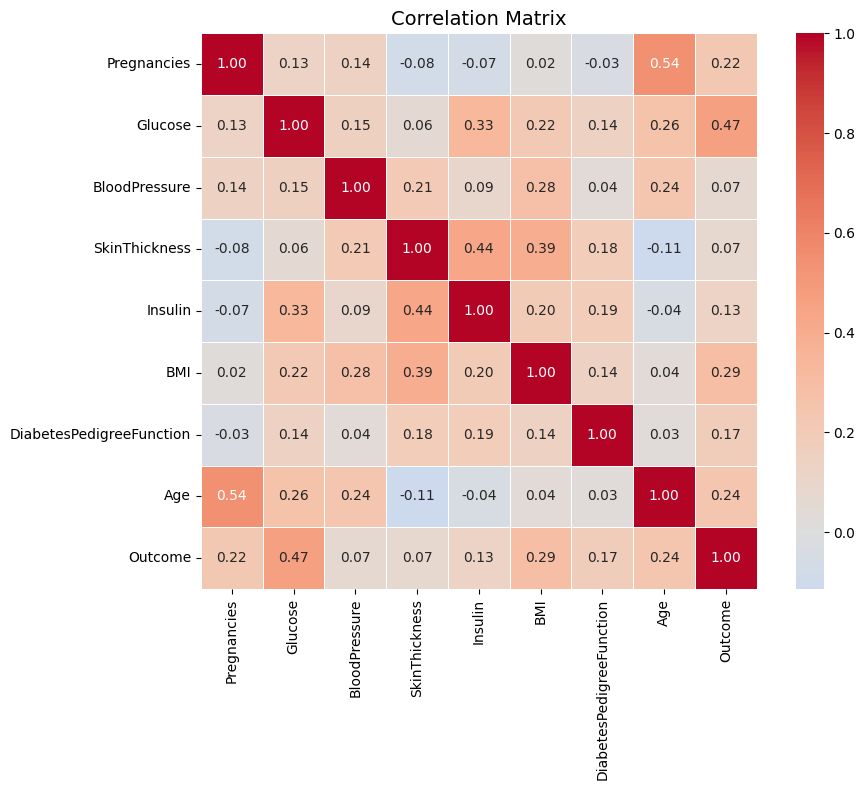

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(),
            annot=True,          # show correlation values
            fmt='.2f',           # 2 decimal places
            cmap='coolwarm',     # color scheme
            center=0,            # center colormap at 0
            square=True,         # square cells
            linewidths=0.5)      # grid lines

plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

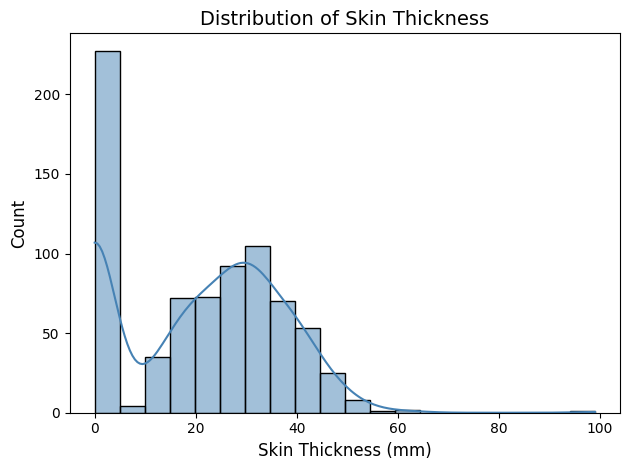

In [23]:
sns.histplot(df['SkinThickness'], bins=20, kde=True, color='steelblue', edgecolor='black')

plt.title('Distribution of Skin Thickness', fontsize=14)
plt.xlabel('Skin Thickness (mm)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

#High peak at 0, rest of the distribution looks normal, Outliers are hurting the distribution.

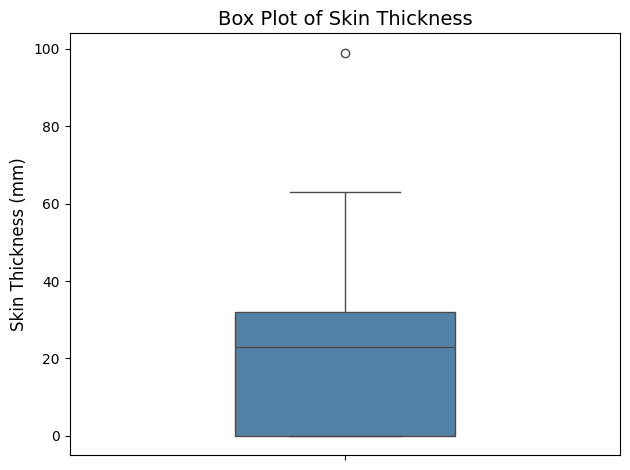

In [24]:
sns.boxplot(y=df['SkinThickness'], color='steelblue', width=0.4)

plt.title('Box Plot of Skin Thickness', fontsize=14)
plt.ylabel('Skin Thickness (mm)', fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
df['Insulin'].value_counts()

,count
Insulin,
0,374
105,11
130,9
140,9
120,8
...,...
178,1
127,1
510,1


In [26]:
(df['Insulin'] < 16).sum()
#~374 values below 16 and 3 values above 600. Unusual.

np.int64(376)

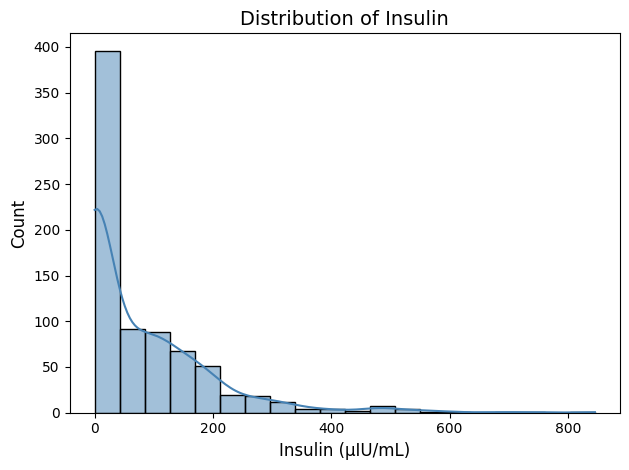

In [27]:
sns.histplot(df['Insulin'], bins=20, kde=True, color='steelblue', edgecolor='black')

plt.title('Distribution of Insulin', fontsize=14)
plt.xlabel('Insulin (µIU/mL)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()
#Right skewed, might still be right skewed even after handling outliers.

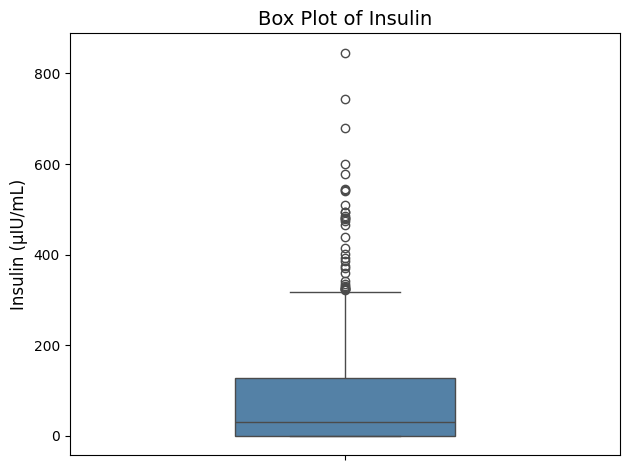

In [28]:
sns.boxplot(y=df['Insulin'], color='steelblue', width=0.4)

plt.title('Box Plot of Insulin', fontsize=14)
plt.ylabel('Insulin (µIU/mL)', fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
df['BMI'].value_counts()

,count
BMI,
32.0,13
31.6,12
31.2,12
0.0,11
32.4,10
...,...
49.6,1
24.1,1
41.2,1


In [30]:
(df['BMI']==0).sum()
#11 values with 0 BMI, unusual.

np.int64(11)

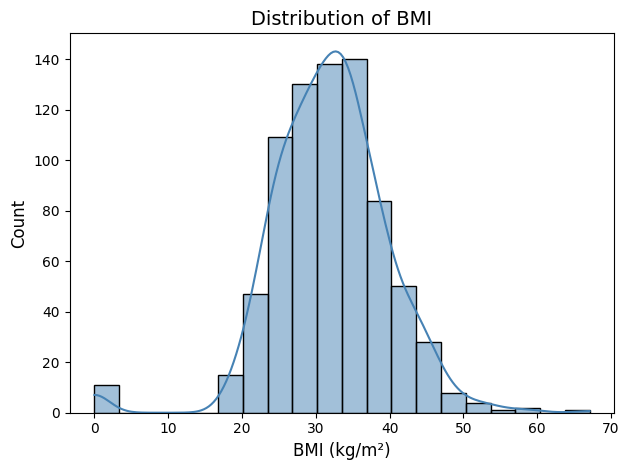

In [31]:
sns.histplot(df['BMI'], bins=20, kde=True, color='steelblue', edgecolor='black')

plt.title('Distribution of BMI', fontsize=14)
plt.xlabel('BMI (kg/m²)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

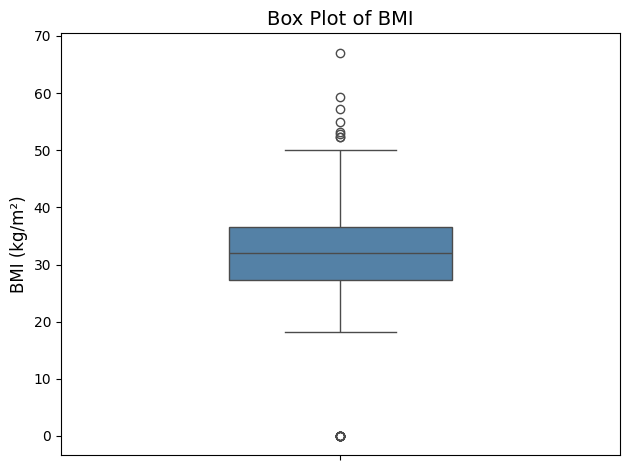

In [32]:
sns.boxplot(y=df['BMI'], color='steelblue', width=0.4)

plt.title('Box Plot of BMI', fontsize=14)
plt.ylabel('BMI (kg/m²)', fontsize=12)
plt.tight_layout()
plt.show()

In [33]:
df['DiabetesPedigreeFunction'].value_counts()

,count
DiabetesPedigreeFunction,
0.258,6
0.254,6
0.207,5
0.261,5
0.259,5
...,...
0.565,1
0.118,1
0.177,1


In [34]:
(df['DiabetesPedigreeFunction']==0).sum()
#No unusual values

np.int64(0)

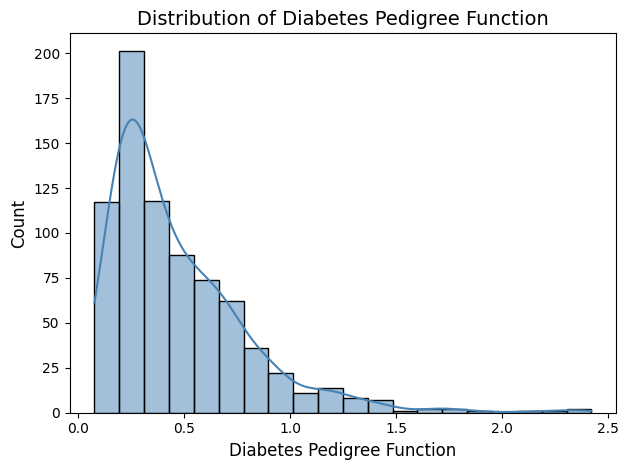

In [35]:
sns.histplot(df['DiabetesPedigreeFunction'], bins=20, kde=True, color='steelblue', edgecolor='black')

plt.title('Distribution of Diabetes Pedigree Function', fontsize=14)
plt.xlabel('Diabetes Pedigree Function', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()
#Valid outliers, but distribution is right skewed.

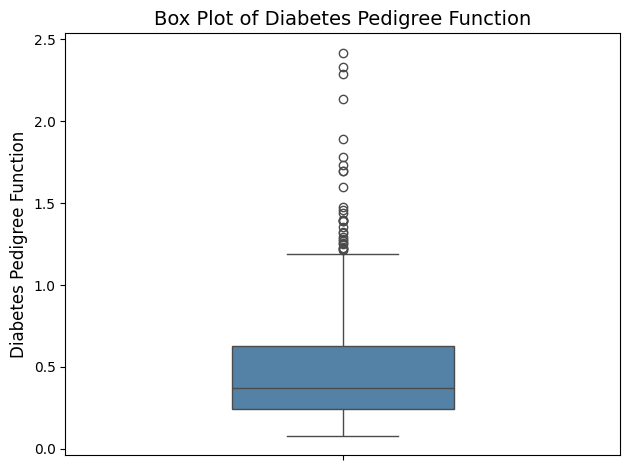

In [36]:
sns.boxplot(y=df['DiabetesPedigreeFunction'], color='steelblue', width=0.4)

plt.title('Box Plot of Diabetes Pedigree Function', fontsize=14)
plt.ylabel('Diabetes Pedigree Function', fontsize=12)
plt.tight_layout()
plt.show()

In [37]:
df['Age'].value_counts()

,count
Age,
22,72
21,63
25,48
24,46
23,38
28,35
26,33
27,32
29,29


In [38]:
(df['Age']==0).sum()

np.int64(0)

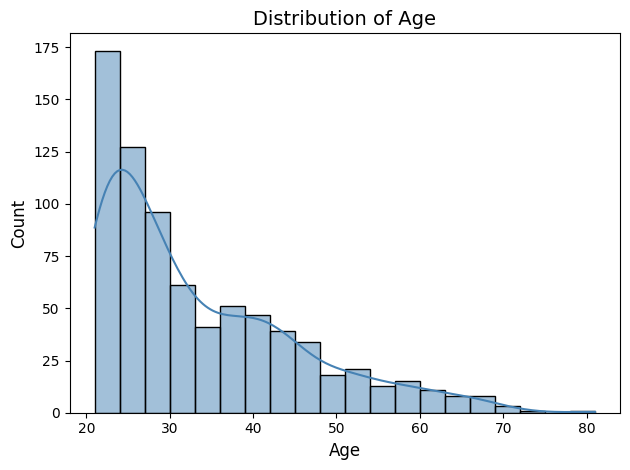

In [39]:
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue', edgecolor='black')

plt.title('Distribution of Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()
#Valid outliers, but also Right skewed.

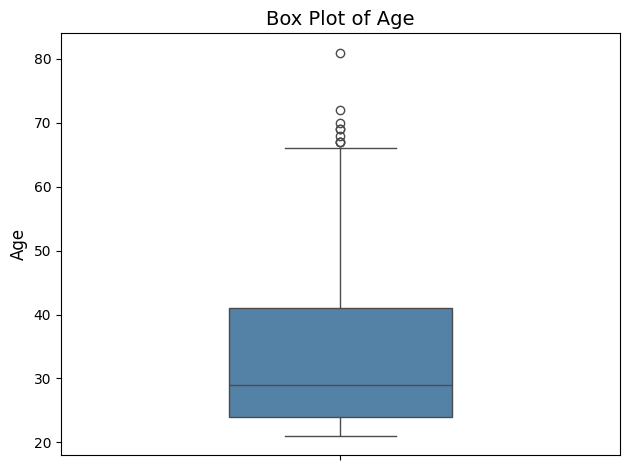

In [40]:
sns.boxplot(y=df['Age'], color='steelblue', width=0.4)

plt.title('Box Plot of Age', fontsize=14)
plt.ylabel('Age', fontsize=12)
plt.tight_layout()
plt.show()

Feature Preprocessing

In [41]:
print("Shape before:", df.shape)

df = df[df['Glucose'] != 0]

print("Shape after:", df.shape)

Shape before: (768, 9)
Shape after: (763, 9)


In [42]:
# Replace 0 and 24 with NaN
df['BloodPressure'] = df['BloodPressure'].replace([0, 24], np.nan)
df['BloodPressure'].isna().sum()

np.int64(36)

In [43]:
# Fill NaN with median grouped by Outcome
df['BloodPressure'] = df.groupby('Outcome')['BloodPressure'].transform(
    lambda x: x.fillna(x.median())
)

df['BloodPressure'].isna().sum()

np.int64(0)

In [44]:
df['SkinThickness'] = df['SkinThickness'].replace([0, 99], np.nan)

df['SkinThickness'] = df.groupby('Outcome')['SkinThickness'].transform(
    lambda x: x.fillna(x.median())
)

In [45]:
Insulin_temp = df['Insulin']

In [46]:
from sklearn.impute import KNNImputer

# First replace 0s with NaN
df['Insulin'] = df['Insulin'].replace(0, np.nan)

# Apply KNN Imputation
imputer = KNNImputer(n_neighbors=5)

# Impute only Insulin column but using all features for distance calculation
df['Insulin'] = imputer.fit_transform(df[['Pregnancies', 'Glucose', 'BloodPressure',
                                          'SkinThickness', 'BMI',
                                          'DiabetesPedigreeFunction',
                                          'Age', 'Insulin']])[:, -1]

print("Missing values after imputation:", df['Insulin'].isna().sum())
print(df['Insulin'].describe())

Missing values after imputation: 0
count    763.000000
mean     153.460813
std       98.300130
min       14.000000
25%       88.000000
50%      135.000000
75%      189.700000
max      846.000000
Name: Insulin, dtype: float64


In [47]:
# Suppose your column name is 'feature'

# Step 1: Calculate mean excluding zeros
mean_val = df.loc[df['BMI'] != 0, 'BMI'].mean()

# Step 2: Replace zeros with that mean
df.loc[df['BMI'] == 0, 'BMI'] = mean_val

Train Test Split

In [60]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.2,
                                                      random_state=42,
                                                      stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (610, 8)
X_test shape: (153, 8)
y_train shape: (610,)
y_test shape: (153,)


Model Training

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [63]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

Evaluation

In [64]:
# Evaluation
print("=== Random Forest Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Random Forest Results ===
Accuracy: 0.817
AUC-ROC: 0.8848

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       100
           1       0.80      0.62      0.70        53

    accuracy                           0.82       153
   macro avg       0.81      0.77      0.79       153
weighted avg       0.82      0.82      0.81       153



In [71]:
# Use the original model (without balanced)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Try different thresholds
thresholds = [0.42, 0.35, 0.3, 0.25]

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    recall = classification_report(y_test, y_pred_thresh, output_dict=True)['1']['recall']
    precision = classification_report(y_test, y_pred_thresh, output_dict=True)['1']['precision']
    f1 = classification_report(y_test, y_pred_thresh, output_dict=True)['1']['f1-score']
    accuracy = round(accuracy_score(y_test, y_pred_thresh), 4)

    print(f"Threshold: {thresh} | Recall: {round(recall,2)} | Precision: {round(precision,2)} | F1: {round(f1,2)} | Accuracy: {accuracy}")

Threshold: 0.42 | Recall: 0.74 | Precision: 0.75 | F1: 0.74 | Accuracy: 0.8235
Threshold: 0.35 | Recall: 0.75 | Precision: 0.7 | F1: 0.73 | Accuracy: 0.8039
Threshold: 0.3 | Recall: 0.77 | Precision: 0.68 | F1: 0.73 | Accuracy: 0.7974
Threshold: 0.25 | Recall: 0.79 | Precision: 0.65 | F1: 0.71 | Accuracy: 0.7778


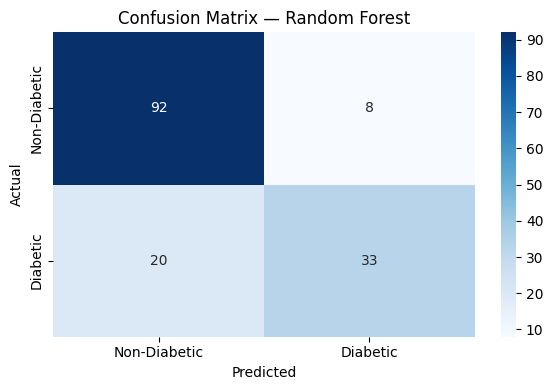

In [53]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

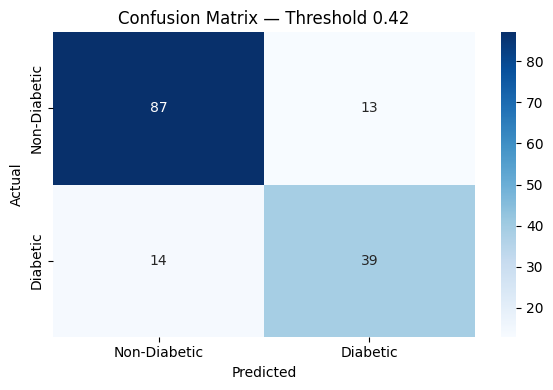

In [72]:
# Final predictions with optimal threshold
y_final_pred = (y_prob >= 0.42).astype(int)

# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_final_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Confusion Matrix — Threshold 0.42')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

                    Feature  Importance
3             SkinThickness    0.214923
1                   Glucose    0.207382
4                   Insulin    0.149750
5                       BMI    0.115841
7                       Age    0.096213
6  DiabetesPedigreeFunction    0.091614
0               Pregnancies    0.062299
2             BloodPressure    0.061978


/tmp/ipykernel_13195/294879467.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='Blues_r')


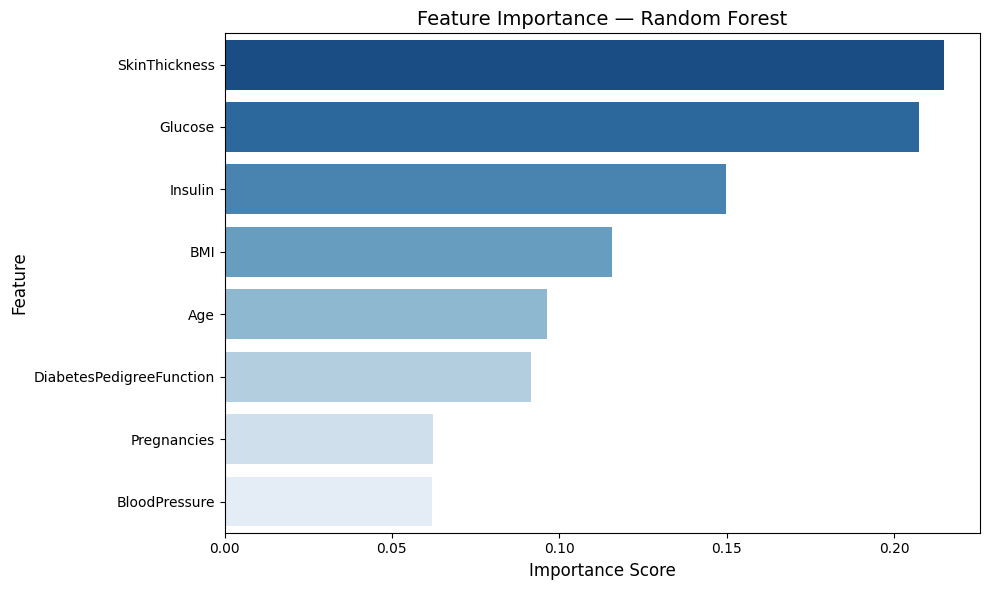

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='Blues_r')

plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

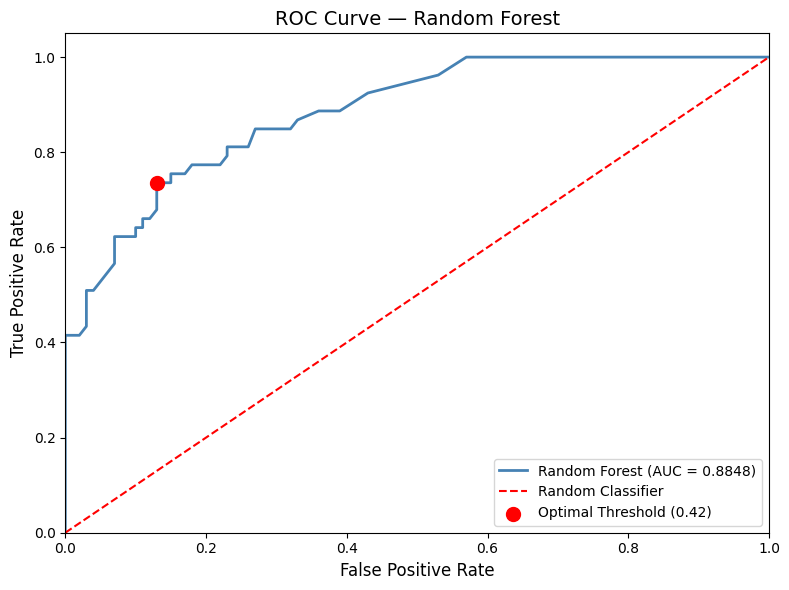

In [77]:
from sklearn.metrics import roc_curve, auc

# Get ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=1.5,
         linestyle='--', label='Random Classifier')

# Mark optimal threshold (0.42)
optimal_idx = np.argmin(np.abs(thresholds - 0.42))
plt.scatter(fpr[optimal_idx], tpr[optimal_idx],
            color='red', s=100, zorder=5,
            label=f'Optimal Threshold (0.42)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Random Forest', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

End of The Project .